# 03 — Feature Engineering
Build climate risk features from extracted 10-K text including keyword frequency,
disclosure length trends, and a composite climate risk score per company per year.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CLEANED_DIR = Path("../data/cleaned")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEANED_DIR / "extracted_sections.csv")
print(f"Loaded {len(df)} filings")
df.head()

Loaded 448 filings


,ticker,year,item_1a,item_7,item_1a_words,item_7_words
0,AAPL,2017,8,and Analysis of Financial Condition and Result...,1,10
1,AAPL,2018,8,and Analysis of Financial Condition and Result...,1,10
2,AAPL,2019,5,and Analysis of Financial Condition and Result...,1,10
3,AAPL,2020,5,and Analysis of Financial Condition and Result...,1,10
4,AAPL,2021,6,and Analysis of Financial Condition and Result...,1,10


In [2]:
# Fix year values - extract from ticker/filing metadata
print("Year distribution before fix:")
print(df["year"].value_counts().sort_index())

# Drop rows with year=0 or null
df = df[df["year"] > 2000].copy()

print(f"\nAfter fix: {len(df)} filings")
print("Year distribution after fix:")
print(df["year"].value_counts().sort_index())

Year distribution before fix:
year
2015    47
2016    48
2017    48
2018    50
2019    51
2020    51
2021    50
2022    52
2023    51
Name: count, dtype: int64

After fix: 448 filings
Year distribution after fix:
year
2015    47
2016    48
2017    48
2018    50
2019    51
2020    51
2021    50
2022    52
2023    51
Name: count, dtype: int64


In [3]:
# Climate risk keyword lexicon grouped by category
KEYWORDS = {
    "physical_risk": [
        "flood", "drought", "wildfire", "hurricane", "extreme weather",
        "sea level", "heat stress", "physical risk", "natural disaster",
        "storm", "precipitation", "temperature increase"
    ],
    "transition_risk": [
        "carbon", "emissions", "greenhouse gas", "ghg", "net zero",
        "carbon neutral", "transition risk", "stranded asset", "carbon tax",
        "cap and trade", "renewable energy", "low carbon", "decarbonization"
    ],
    "regulatory": [
        "epa", "paris agreement", "climate regulation", "carbon regulation",
        "tcfd", "sec climate", "climate disclosure", "environmental regulation",
        "climate policy", "climate legislation"
    ],
    "opportunity": [
        "clean energy", "sustainability", "esg", "climate opportunity",
        "green", "sustainable", "climate strategy", "climate initiative"
    ]
}

# Flatten for total count
ALL_KEYWORDS = [kw for group in KEYWORDS.values() for kw in group]
print(f"Total keywords: {len(ALL_KEYWORDS)} across {len(KEYWORDS)} categories")

Total keywords: 43 across 4 categories


In [4]:
def count_keywords(text, keywords):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    text_lower = text.lower()
    return sum(text_lower.count(kw) for kw in keywords)

# Count keywords per category in Item 1A
for category, keywords in KEYWORDS.items():
    df[f"1a_{category}"] = df["item_1a"].apply(
        lambda x: count_keywords(x, keywords)
    )

# Total climate keyword count
df["1a_total_climate_keywords"] = df[[f"1a_{cat}" for cat in KEYWORDS]].sum(axis=1)

# Disclosure length features
df["1a_word_count"] = df["item_1a_words"]
df["7_word_count"] = df["item_7_words"]

# Keyword density (keywords per 1000 words)
df["1a_keyword_density"] = (
    df["1a_total_climate_keywords"] / (df["1a_word_count"] / 1000)
).replace([np.inf, -np.inf], 0).fillna(0)

print("Features created:")
print(df[["ticker", "year", "1a_total_climate_keywords", "1a_keyword_density"]].head(10))

Features created:
  ticker  year  1a_total_climate_keywords  1a_keyword_density
0   AAPL  2017                          0            0.000000
1   AAPL  2018                          0            0.000000
2   AAPL  2019                          0            0.000000
3   AAPL  2020                          0            0.000000
4   AAPL  2021                          0            0.000000
5   AAPL  2022                          0            0.000000
6   AAPL  2023                          0            0.000000
7   AAPL  2015                          0            0.000000
8   AAPL  2016                          0            0.000000
9   ABBV  2015                         27            3.731343


In [5]:
from sklearn.preprocessing import MinMaxScaler

feature_cols = [
    "1a_total_climate_keywords",
    "1a_keyword_density", 
    "1a_physical_risk",
    "1a_transition_risk",
    "1a_regulatory",
    "1a_word_count"
]

# Filter to rows with actual content
df_scored = df[df["1a_word_count"] > 100].copy()

# Normalize each feature to 0-1
scaler = MinMaxScaler()
df_scored[feature_cols] = scaler.fit_transform(df_scored[feature_cols])

# Weighted composite score
weights = {
    "1a_total_climate_keywords": 0.30,
    "1a_keyword_density":        0.25,
    "1a_physical_risk":          0.15,
    "1a_transition_risk":        0.15,
    "1a_regulatory":             0.10,
    "1a_word_count":             0.05,
}

df_scored["climate_risk_score"] = sum(
    df_scored[col] * weight for col, weight in weights.items()
)

print(df_scored[["ticker", "year", "climate_risk_score"]].sort_values(
    "climate_risk_score", ascending=False).head(15).to_string(index=False))

ticker  year  climate_risk_score
   CVX  2023            0.829114
   CVX  2022            0.741752
   CVX  2017            0.594924
   CVX  2020            0.543844
   CVX  2018            0.540530
   DUK  2023            0.540373
   CVX  2021            0.531584
   DUK  2022            0.531511
   CVX  2019            0.531152
   CVX  2016            0.523750
   DUK  2021            0.458296
   DUK  2020            0.413242
   JNJ  2023            0.408533
   JNJ  2022            0.402118
   DUK  2019            0.387505


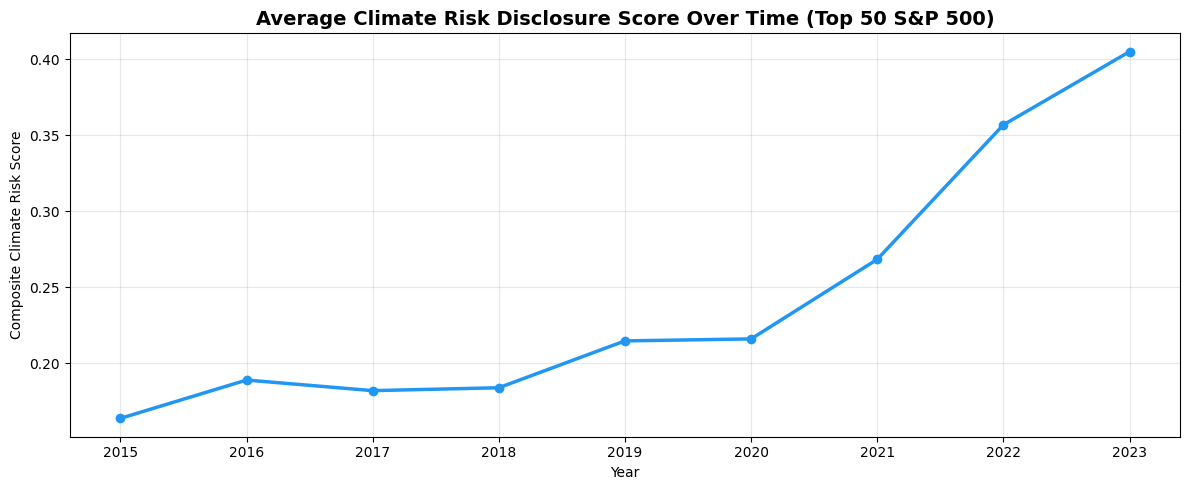

Chart saved.


In [6]:
# Average climate risk score by year
yearly_trend = df_scored.groupby("year")["climate_risk_score"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly_trend["year"], yearly_trend["climate_risk_score"], 
         marker="o", linewidth=2.5, color="#2196F3")
plt.title("Average Climate Risk Disclosure Score Over Time (Top 50 S&P 500)", 
          fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Composite Climate Risk Score")
plt.xticks(yearly_trend["year"].astype(int))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/climate_score_trend.png", dpi=150)
plt.show()
print("Chart saved.")